# 실외 환경에서 날개 박자는 살아남나

**2026-09-01 · matrice4e · 15 m · 자세 8,192 · 스톡 엔진(추가 물리 끔) · 광선 4e9 · 깊이 2**

---

## 한 줄 결론

> **빗각에서 또렷하던 날개 줄무늬가 지면·건물을 넣으면 사라지고, 정지 클러터를 걷어내도 안 돌아온다.**
> 환경 에코는 **정지 성분이 아니다** — 제거해도 변동의 99 %가 그대로 남고, 잔차가 자유공간
> 신호와 닮지도 않는다(|상관| 0.02). 노치를 5 → 120 Hz로 넓혀도 똑같다.

⛔ **이 보고서에 우리 커널은 없다.** 이유는 §5 에 있다.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_formats = ["png"]
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

ROOT = "/workspace/sionna"
sys.path.insert(0, f"{ROOT}/benchmark")
sys.path.insert(0, f"{ROOT}/src")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")   # ⛔GPU 를 쓰지 않는다

from clutter_parts_ladder_0824 import cs_eca, PRF, FFL, FCUT

Z = np.load(f"{ROOT}/outputs/elevation_sweep_md.npz")
MESH = "mfixbatteryi5_blperairframe"
ELS  = [0.0, -30.0, -60.0]

def arm(el, env=False):
    tag = "_envoutdoor01" if env else ""
    return f"sionna_p4000000000_swR0D0E0F1_r15_n8192{tag}_{MESH}_d2/el{el:+.0f}"

print(f"PRF {PRF:.0f} Hz · f_flash {FFL:.2f} Hz · ECA 노치 {FCUT:.0f} Hz")
print(f"원장 팔 {len(Z.files)} 개")

PRF 19700 Hz · f_flash 126.67 Hz · ECA 노치 100 Hz
원장 팔 1434 개


## 1. 잣대 — 포락 자기상관 ρ

`ρ` 는 포락의 **1 지연 자기상관**이다. 0 근처면 되풀이되는 박자가 없다는 뜻이고, dB 값이
아무리 커도 그렇다.

⭐ **왜 dB 를 안 쓰나** — dB 잣대는 «봉우리 ÷ 바닥» 비라 **몇 자세짜리 낙차 임펄스열**에도
큰 값을 준다. 2026-08-31 적대 검증에서 실제로 그 함정에 빠진 것이 발견됐다(el 0 기록의
변동 100 %가 8,192 자세 중 19~52 개의 낙차였는데 dB 는 9.5 를 줬다).
대체 잣대 넷 중 **살아남은 것은 ρ 하나뿐**이다.

In [ ]:
def rho(E):
    """포락 자기상관(1 지연). 잡음 −0.06~+0.07 · 박자 +0.92~+0.99"""
    a  = np.abs(np.asarray(E))
    ac = a - a.mean()
    d  = float(np.dot(ac, ac))
    return float(np.dot(ac[:-1], ac[1:]) / d) if d > 0 else np.nan

def corr(a, b):
    """|상관| — 잔차가 목표와 닮았나"""
    a = np.asarray(a) - np.mean(a); b = np.asarray(b) - np.mean(b)
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(abs(np.vdot(a, b)) / d) if d > 0 else np.nan

def lvl(E):
    return 20 * np.log10(np.abs(np.asarray(E)).mean())

## 2. 세 판의 ρ — 자유공간 · 실외 · 실외+제거

In [ ]:
rows = []
for el in ELS:
    F = np.asarray(Z[arm(el, False)])      # 자유공간
    O = np.asarray(Z[arm(el, True)])       # 실외
    R = cs_eca(O)                          # 실외 + 정지 클러터 제거
    ac0 = float(np.sum(np.abs(O - O.mean())**2))
    ac1 = float(np.sum(np.abs(R - R.mean())**2))
    rows.append(dict(el=el, rho_free=rho(F), rho_out=rho(O), rho_rem=rho(R),
                     d_level=lvl(O) - lvl(F), corr_rem_vs_free=corr(R, F),
                     ac_left=100 * ac1 / ac0))

hdr = f"{'앙각':>6}{'자유공간 ρ':>13}{'실외 ρ':>11}{'제거 후 ρ':>12}{'레벨 변화':>12}{'|상관| 잔차↔자유':>18}{'AC 남은몫':>11}"
print(hdr); print("-" * len(hdr))
for r in rows:
    print(f"{r['el']:>+6.0f}{r['rho_free']:>+13.3f}{r['rho_out']:>+11.3f}{r['rho_rem']:>+12.3f}"
          f"{r['d_level']:>+11.1f} dB{r['corr_rem_vs_free']:>18.4f}{r['ac_left']:>10.1f}%")

    앙각       자유공간 ρ       실외 ρ      제거 후 ρ       레벨 변화        |상관| 잔차↔자유     AC 남은몫
-----------------------------------------------------------------------------------
    +0       +0.021     +0.019      +0.038       +0.4 dB            0.9021      99.1%
   -30       +0.974     +0.005      +0.039      +53.6 dB            0.0228      98.7%
   -60       +0.992     +0.002      +0.027      +45.1 dB            0.0271      98.9%


**읽는 법**

- **자유공간** — 빗각 두 곳이 +0.97 / +0.99 로 박자가 또렷하다. 정면(el 0)은 +0.02 로
  이미 잡음인데, 그건 이 실험 이전부터 알려진 «정면 붕괴» 다.
- **실외** — 빗각 두 곳이 +0.005 / +0.002 로 **무너진다.** 동시에 레벨이 45~54 dB 오른다
  (지면·건물 에코).
- **제거 후** — +0.03~+0.04. 안 돌아온다. 그리고 **AC 의 99 %가 그대로 남는다** —
  걷어낸 것이 거의 없다는 뜻이다.

## 3. 노치 폭을 바꿔 봐도 같다

정지 클러터 제거(`cs_eca`)는 DFT 격자에서 `|f| ≤ fcut` 칸을 투영으로 들어낸다.
정본은 100 Hz(박자 126.7 Hz 아래라 신호는 안 건드린다). 폭을 바꿔 본다.

In [ ]:
cuts = [5.0, 20.0, 60.0, 100.0, 120.0]
print(f"{'앙각':>6}" + "".join(f"{('fcut ' + str(int(c))):>22}" for c in cuts))
for el in (-30.0, -60.0):
    F = np.asarray(Z[arm(el, False)]); O = np.asarray(Z[arm(el, True)])
    line = f"{el:>+6.0f}"
    for c in cuts:
        R = cs_eca(O, fcut=c)
        line += f"   ρ {rho(R):+.3f} |r| {corr(R, F):.3f}"
    print(line)

    앙각                fcut 5               fcut 20               fcut 60              fcut 100              fcut 120
   -30   ρ +0.005 |r| 0.023   ρ +0.010 |r| 0.023   ρ +0.027 |r| 0.023   ρ +0.039 |r| 0.023   ρ +0.040 |r| 0.023
   -60   ρ +0.004 |r| 0.027   ρ +0.008 |r| 0.027   ρ +0.017 |r| 0.027   ρ +0.027 |r| 0.027   ρ +0.030 |r| 0.027


**어디를 잘라도 같다.** ρ 는 0.04 를 못 넘고, 자유공간과의 |상관| 은 **소수점 셋째 자리까지
움직이지 않는다.**

### ⚠ 대조 — 필터 자체는 멀쩡하다

자유공간 신호에 같은 제거를 걸면 박자가 그대로 살아 있다.

In [ ]:
for el in (-30.0, -60.0):
    F = np.asarray(Z[arm(el, False)])
    print(f"el {el:+.0f}°   제거 전 ρ {rho(F):+.3f}  →  제거 후 ρ {rho(cs_eca(F)):+.3f}")

el -30°   제거 전 ρ +0.974  →  제거 후 ρ +0.987
el -60°   제거 전 ρ +0.992  →  제거 후 ρ +0.979


## 4. 맵으로 보기

`benchmark/build_switch_grid_figs.py` 의 정본 STFT 규약을 그대로 쓴다
(조각 길이 = 블레이드 0.6 주기). ⚠`FT30` 이 임포트 시점에 `SWGRID_EL` 로 굳으므로
**앙각마다 모듈을 다시 불러온다.**

/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from f

/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s)

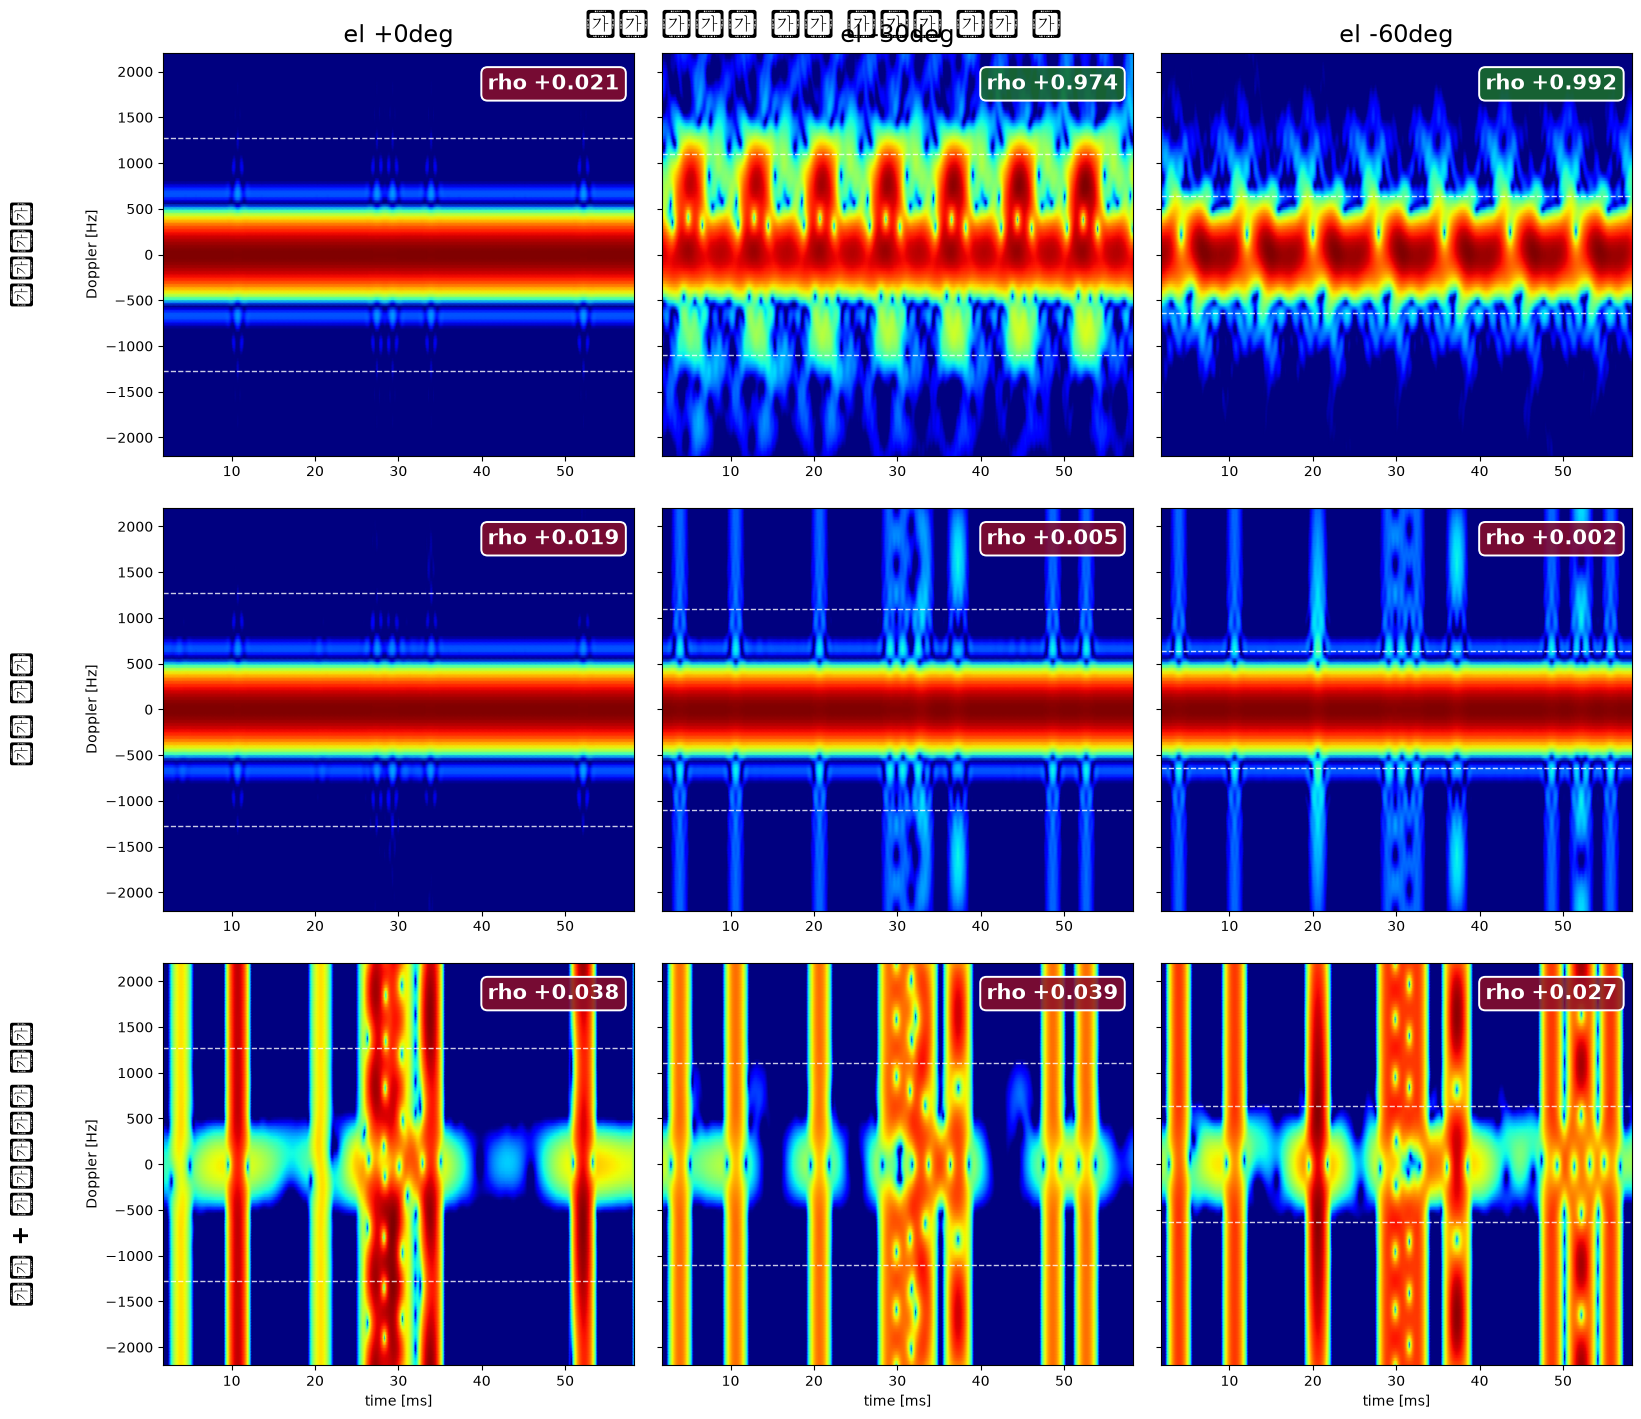

/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)


/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-pack

/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/IPython/core/events.py:101: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/workspace/.venvs/py312/lib/python3.12/site-packages/I

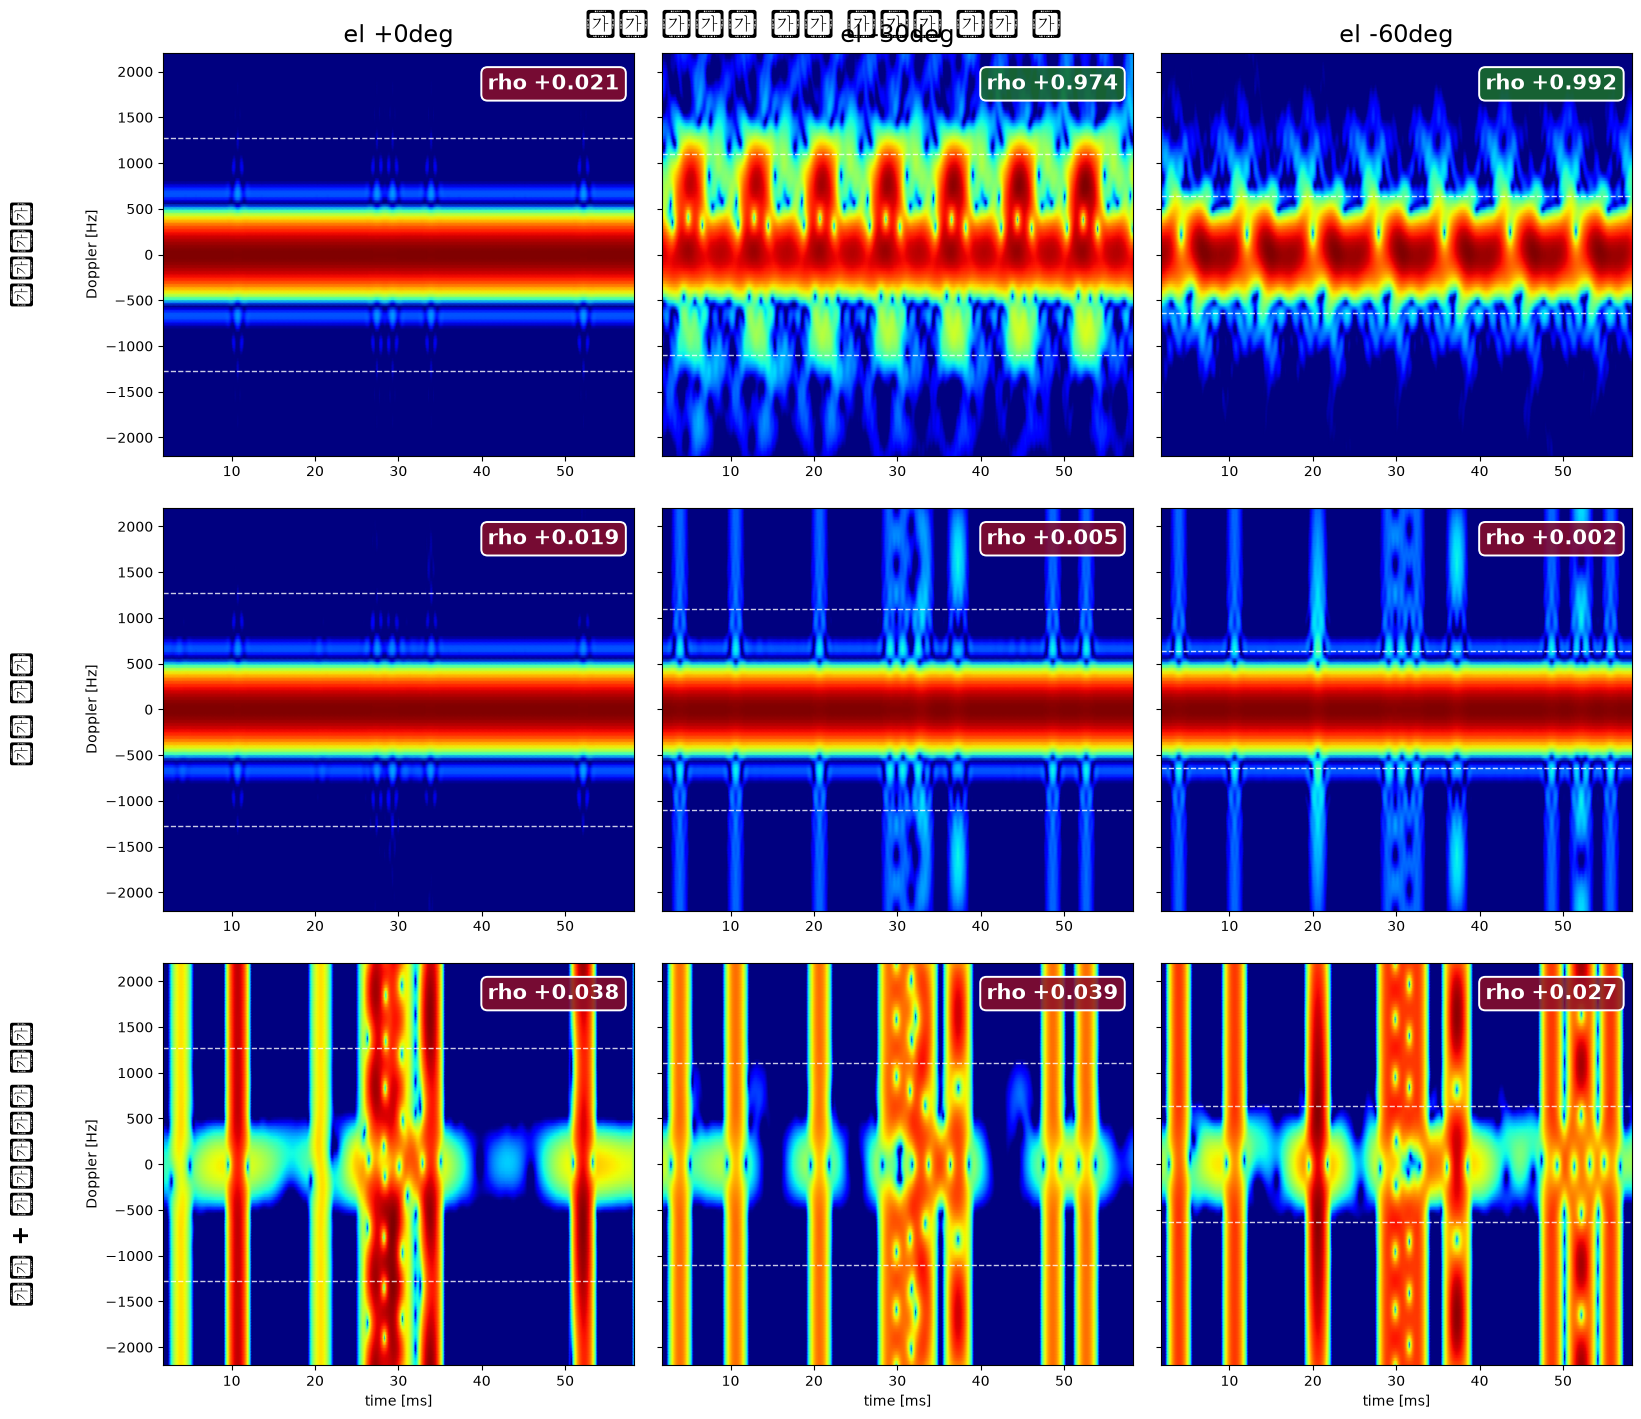

In [ ]:
import importlib

def grid_mod(el):
    """⚠앙각마다 다시 불러온다 — FT30 이 임포트 때 굳는다"""
    os.environ["SWGRID_EL"] = f"{el:g}"
    import build_switch_grid_figs as M
    importlib.reload(M)
    return M

ROWS = [("자유공간",              False, False),
        ("실외 환경",             True,  False),
        ("실외 + 정지클러터 제거", True,  True)]

fig, ax = plt.subplots(3, 3, figsize=(16.5, 14.5), squeeze=False)
for r, (lab, use_env, remove) in enumerate(ROWS):
    for c, el in enumerate(ELS):
        M = grid_mod(el)
        E = np.asarray(Z[arm(el, use_env)])
        if remove:
            E = cs_eca(E)
        n0 = int(round(M.T0 * M.PRF)); nz = int(round(M.TSPAN * M.PRF))
        f_, t_, S_, _ = M.flash_spec(E[n0:n0 + nz], M.PRF, M.FFL, M.PERIODS)
        a = ax[r, c]
        M.draw(a, t_, f_, S_, M.FT30)
        a.set_ylim(-2200, 2200)
        if r == 0:
            a.set_title(f"el {el:+.0f}deg", fontsize=17, pad=8)
        if r == 2:
            a.set_xlabel("time [ms]")
        a.set_ylabel("Doppler [Hz]" if c == 0 else "")
        if c:
            a.set_yticklabels([])
        rr = rho(E); ok = abs(rr) > 0.10
        a.text(0.97, 0.95, f"rho {rr:+.3f}", transform=a.transAxes, ha="right", va="top",
               fontsize=15, weight="bold", color="white",
               bbox=dict(boxstyle="round,pad=0.3", ec="white", lw=1.4,
                         fc=(0.10, 0.45, 0.15, 0.85) if ok else (0.55, 0.05, 0.15, 0.85)))
    ax[r, 0].text(-0.30, 0.5, lab, transform=ax[r, 0].transAxes, rotation=90,
                  ha="center", va="center", fontsize=17, weight="bold")
fig.subplots_adjust(top=0.955, bottom=0.05, left=0.10, right=0.99, hspace=0.13, wspace=0.06)
fig.suptitle("실외 환경이 날개 박자에 하는 일", fontsize=21, weight="bold", y=0.985)
fig    # ⭐마지막 표현식으로 두어야 노트북에 박힌다

**윗줄** — 지금까지 우리가 읽어 온 줄무늬.
**가운데** — 지면·건물을 넣으면 0 Hz 굵은 띠만 남는다. 간간이 서는 세로 줄은 박자가 아니라
산발적 사건이다.
**아랫줄** — 노치가 띠는 걷었는데 **줄무늬는 안 돌아온다.** 새로 생긴 굵은 세로 줄은
노치가 만든 잔향이다.

⭐ **0827 에 정면에서 봤던 것과 판박이다.** 그때도 «띠는 걷혔는데 박자는 없고 노치 잔향만
남았다» 였다. 이번엔 거울이 동체가 아니라 **지면·건물**이고, 그래서 **각도로도 못 피한다** —
−30° 와 −60° 가 똑같이 무너진다.

## 5. ⛔ 이 보고서에 우리 커널이 없는 이유

`--env` 는 **PathSolver 씬에만** 붙는다. 우리 커널은 `sbr_field(mv, ...)` 를 부르는데
`mv` 는 **자세 잡힌 드론 메쉬**뿐이라 환경 부품이 도달하지 않는다.

실제로 `ours` 의 `_envoutdoor01` 샤드는 자유공간 샤드와 **상대차 1e−16**(float64 엡실론)
이었다. 이름만 실외였다. **그 6 개는 2026-09-01 에 지웠고**, 이제
`--engine ours --env` 는 **거부된다**.

### 왜 그런 구조인가 — 격자가 표적 bbox 로 정해진다

우리 커널은 표적 경계구에 맞춘 균일 광선 격자를 쏜다.
`n = ceil(2·R_out/d)`, `R_out = R_max·1.15 + 3d`, `d = λ/12`.

In [ ]:
from rcs_sbr import DEFAULT_DIV

lam = 2.998e8 / 3.5e9
d   = lam / DEFAULT_DIV
pad = 1.15

def grid_cost(Rmax, label):
    Rout = Rmax * pad + 3 * d
    n    = int(np.ceil(2 * Rout / d))
    return dict(label=label, Rmax=Rmax, n=n, pts=n * n)

cases = [grid_cost(0.28,                 "드론만 (지금)"),
         grid_cost(np.hypot(60, 60),     "+ 지면 120 x 120 m"),
         grid_cost(np.hypot(1.0, 1.0),   "+ 지면 2 x 2 m 패치"),
         grid_cost(np.hypot(2.5, 2.5),   "+ 지면 5 x 5 m 패치")]
base = cases[0]["pts"]

print(f"격자 간격 lambda/{DEFAULT_DIV} = {d*1000:.2f} mm\n")
print(f"{'표적':<24}{'R_max':>10}{'격자 n':>10}{'격자점':>18}{'드론 대비':>12}")
print("-" * 74)
for c in cases:
    print(f"{c['label']:<24}{c['Rmax']:>8.2f} m{c['n']:>10,}{c['pts']:>18,}"
          f"{c['pts']/base:>11,.0f}x")

격자 간격 lambda/12 = 7.14 mm

표적                           R_max      격자 n               격자점       드론 대비
--------------------------------------------------------------------------
드론만 (지금)                    0.28 m        97             9,409          1x
+ 지면 120 x 120 m           84.85 m    27,347       747,858,409     79,483x
+ 지면 2 x 2 m 패치             1.41 m       462           213,444         23x
+ 지면 5 x 5 m 패치             3.54 m     1,146         1,313,316        140x


**격자가 표적 크기의 제곱으로 큰다.** 드론 0.5 m 에서 장면 120 m 로 가면 선형 240 배,
광선 **약 8 만 배**다. 자세 8,192 개에 곱하면 못 돈다.

⇒ 설계 실수가 아니라 **SBR 격자가 bbox 로 정해진다는 구조의 결과**다. PathSolver 는 광선을
쏘고 부딪히는 것을 찾으니 장면이 커져도 되지만, 우리 커널은 표적을 격자로 덮는 방식이라 다르다.

### ⭐ 그런데 온 지면이 필요한 게 아니다

지면 반사를 실어 나르는 것은 **정반사점 둘레의 제1 프레넬 존**이다.

In [ ]:
for el, r_m in ((30, 15.0), (60, 15.0)):
    d1 = d2 = r_m
    R1 = np.sqrt(lam * d1 * d2 / (d1 + d2))
    print(f"el -{el}deg · d1=d2={r_m:.0f} m  ->  제1 프레넬 반경 {R1*100:.0f} cm "
          f"(지름 {2*R1:.2f} m)")
print()
print("⇒ 2 x 2 m 패치면 드론만 대비 23 배 — 감당된다.")
print("⇒ 120 m 평면은 79,483 배 — 못 한다.")

el -30deg · d1=d2=15 m  ->  제1 프레넬 반경 80 cm (지름 1.60 m)
el -60deg · d1=d2=15 m  ->  제1 프레넬 반경 80 cm (지름 1.60 m)

⇒ 2 x 2 m 패치면 드론만 대비 23 배 — 감당된다.
⇒ 120 m 평면은 79,483 배 — 못 한다.


**반사에 실제로 기여하는 지면 조각만 주면 우리 커널도 돌 수 있다.** 그것이 다음 주 작업이다.

그 전까지 정직한 진술은 — **우리 커널은 실외 장면에서 한 번도 안 돌았다.**

---

## 부록 · 재현

```
cd /workspace/sionna
CUDA_VISIBLE_DEVICES="" PYTHONPATH=src:benchmark \
  /workspace/.venvs/py312/bin/python -m jupyter nbconvert --execute --inplace \
  /workspace/sionna/docs/OUTDOOR_SCENE_0901.ipynb
```

| | |
|---|---|
| 원장 | `outputs/elevation_sweep_md.npz` |
| 제거 | `benchmark/clutter_parts_ladder_0824.cs_eca` |
| STFT 규약 | `benchmark/build_switch_grid_figs.py` (조각 = 블레이드 0.6 주기) |
| 환경 메쉬 | `assets/meshes/outdoor01` — 지면 120×120 m · 건물 넷 9~24 m · 기둥 둘 |
| 만든 스크립트 | `benchmark/make_outdoor_scene_0831.py` |
| 팔 이름 | `sionna_p4000000000_swR0D0E0F1_r15_n8192[_envoutdoor01]_mfixbatteryi5_blperairframe_d2` |